In [17]:
import qutip as qt
import torch as tc
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import function as my
import matplotlib.pyplot as plt

from tqdm import tqdm

class SIN(tc.nn.Module):
    def __init__(self): 
        super(SIN, self).__init__() 
    def forward(self, x):
        return tc.sin(x)

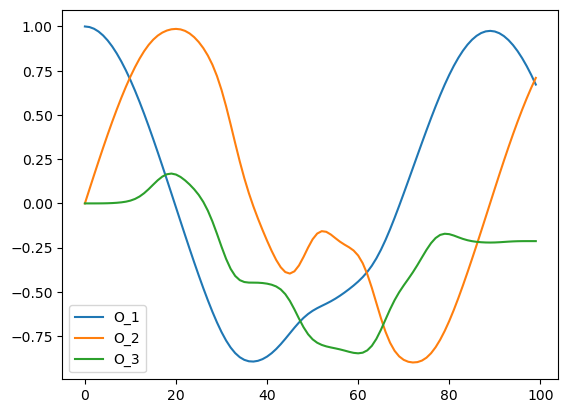

In [18]:
O_op =[ qt.sigmax(),
         qt.sigmay(),
         qt.sigmaz()
                ]

def Field(t):
    return ( 1.5* np.sin(2.0 * t) - 0.3*np.cos(3* t - 0.5) + 0.4*np.sin(7.0 * t)
        )*np.sin(np.pi*t/tfinal)**2


def data_qubit(O_op,tlist,field,device="cpu"):
    # Lista de tempos para a evolução
    H0 = 0.5*qt.sigmaz()
    H1 = 0.5*qt.sigmax()
    H  = [H0,[H1,field(tlist)]]
    
    # Hamiltonian Lindbladian
    c_ops = []
    
    # Estado inicial (cada qubit na superposição de |0> e |1>)
    # |+> = (|0> + |1>)/sqrt(2)
    theta1  = np.pi/4
    phi1    = 0.0 #np.pi/3
    ket_plus1 = (np.cos(theta1)*qt.basis(2, 0)+np.sin(theta1)*np.exp(1j*phi1)*qt.basis(2, 1))
    psi0 = ket_plus1
    
    # Solução da equação de Schrödinger
    options = qt.Options(nsteps = 100000, atol = 1e-14, rtol = 1e-14)
    result  = qt.mesolve(H, psi0, tlist, c_ops=c_ops, e_ops=O_op,options=options)

    expect  = tc.tensor( np.array( result.expect),device = device).transpose(0, 1)
    return expect


tfinal      = 2.52*np.pi
N           = 100
Nedo        = 3
Nfield      = 0

tlist       = np.linspace(0.0, tfinal, N)
valor_esperado_data  = data_qubit(O_op,tlist,Field,device="cpu")

for i in range(len(O_op)):
    plt.plot(valor_esperado_data[:,i].cpu() ,label=f"O_{i+1}")

plt.legend()
plt.show()


In [19]:
# 3. Fourier Expansion (Refinado)
M_HARMONICS = 10
T_PERIOD = tlist.max() - tlist.min()
n_range = tc.arange(1, M_HARMONICS + 1, dtype=tc.float32).view(1, -1)

def get_fourier_field(t, coeffs, n_range, T_PERIOD):
    # coeffs: [a0, an(1..M), bn(1..M)] com tamanho 2*M + 1
    a0 = coeffs[0].view(1, 1)
    an = coeffs[1:1 + M_HARMONICS].view(1, -1)
    bn = coeffs[1 + M_HARMONICS:1 + 2*M_HARMONICS].view(1, -1)

    angles = (2.0 * np.pi / T_PERIOD) * t * n_range
    return a0 + tc.sum(an * tc.cos(angles) + bn * tc.sin(angles), dim=1, keepdim=True)


neuronio = [15,15]
X_vector   = my.Rede(
    neuronio    = neuronio,
    input_      = 1,
    output_     = Nedo+Nfield,
    activation  =[SIN()]*len(neuronio),
    creat_p     =True,
    N_of_paramater=M_HARMONICS*2 + 1
    )
opt = tc.optim.Adam(X_vector.parameters(), lr=0.001,weight_decay=1e-5)
time =  tc.linspace(
        0,
        tfinal,
        N,
        dtype   = tc.float32,
        requires_grad = True).reshape((-1, 1))

JZ = 1e0
JY = 0e0
epocas  = 100000

100%|██████████| 100000/100000 [01:49<00:00, 915.26it/s]


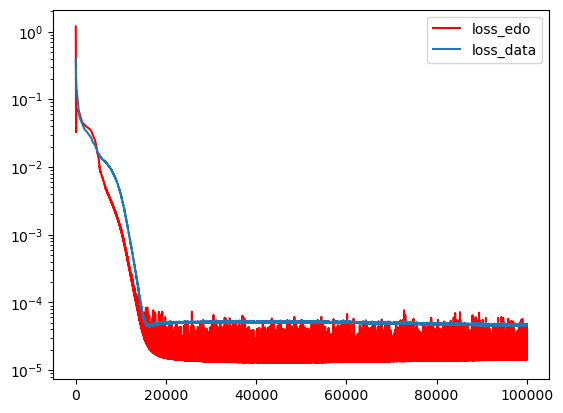

In [20]:
def grad(y, x): 
    return tc.autograd.grad(y, x, tc.ones_like(y), create_graph=True)[0]

LOSS    = []
LOSS1   = []
LOSS2   = []
hisorty_of_param = []
for _ in tqdm(range(epocas)):
    ####### Forward pass #######
    S_pred = X_vector(time)
    
    ######## Loss data #######
    LOSS_data = tc.mean((S_pred - valor_esperado_data) ** 2)

    ######## Loss edo #######
    JX = get_fourier_field(time, X_vector.parametro, n_range, T_PERIOD)
    
    dSx = grad(S_pred[:, 0:1], time)
    dSy = grad(S_pred[:, 1:2], time)
    dSz = grad(S_pred[:, 2:3], time)
    
    X,Y,Z = S_pred[:, 0:1], S_pred[:, 1:2], S_pred[:, 2:3]
   
    LOSS_edo  = 0    
    LOSS_edo += (dSx - (-1.0*Y))**2
    LOSS_edo += (dSy - ( 1.0*X - 1.0*JX*Z))**2
    LOSS_edo += (dSz - ( 1.0*JX*Y))**2
    LOSS_edo = LOSS_edo.mean()
    
    ####### Loss total #######
    loss_i = LOSS_edo + LOSS_data+ (JX[0,0] - Field(0.0))**2 + (JX[-1,0] - Field(tfinal))**2

    ####### Backpropagation #######
    opt.zero_grad()
    loss_i.backward()
    opt.step()
    LOSS1.append(LOSS_edo.cpu().detach().numpy())
    LOSS2.append(LOSS_data.cpu().detach().numpy())
    LOSS.append(loss_i.cpu().detach().numpy())

#plt.plot(LOSS,"k.",label="loss_total")
plt.plot(LOSS1,'r-',label="loss_edo")
plt.plot(LOSS2,label="loss_data")
plt.yscale("log")
plt.legend()
plt.show()


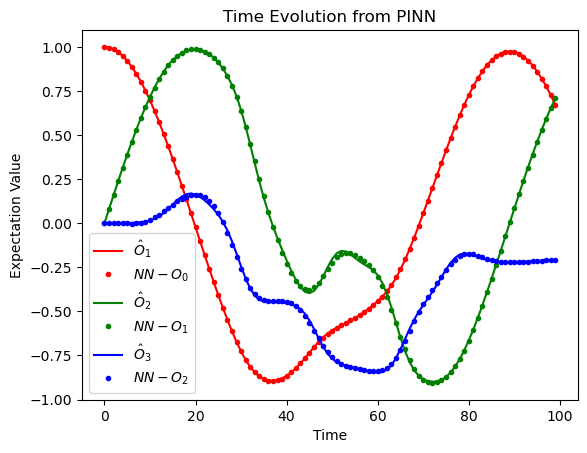

In [21]:
t_points =  np.linspace(0,tfinal, N)
X_vector.eval()
X_  = X_vector(time).detach().numpy()

colors = ['r', 'g', 'b']
for i in range(len(O_op)):
    plt.plot(valor_esperado_data[:,i].cpu() ,label=fr"$\hat{{O}}_{{{i+1}}}$", color=colors[i])
    plt.plot(X_[:,i],"." ,label=fr"$NN - O_{{{i}}}$", color=colors[i])
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('Time Evolution from PINN')
plt.show()

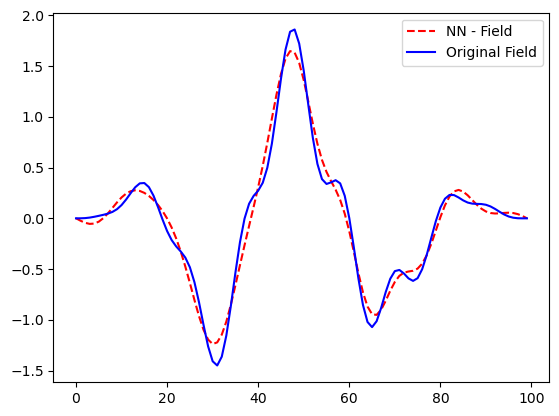

In [22]:
t_points =  np.linspace(0,tfinal, N)
JX_ = get_fourier_field(time, X_vector.parametro, n_range, T_PERIOD).detach().numpy().flatten()

field_original=Field(t_points)
plt.plot(JX_,"r--",label="NN - Field")
plt.plot(field_original,"b-",label="Original Field")
plt.legend()
plt.show()

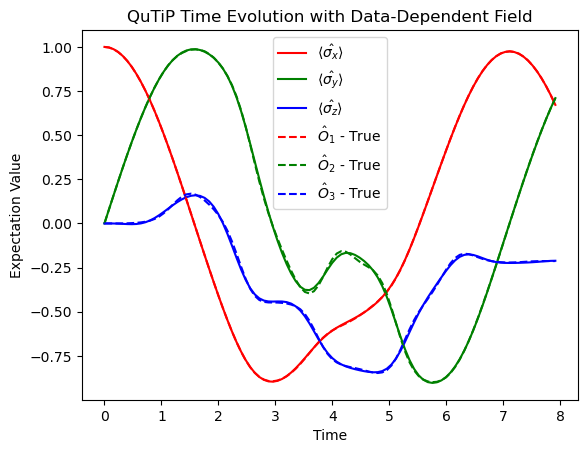

In [23]:
H0 = .5*qt.sigmaz()
H1 = .5*qt.sigmax()
# The full Hamiltonian is defined as a list: 
# H = H0 + f(t) * H1, where f(t) is the field data
H = [H0, [H1, JX_]] # QuTiP uses cubic spline interpolation for field_data

# (Optional) Define collapse operators for an open system simulation
c_ops = [] # e.g., c_ops = [np.sqrt(gamma) * qt.sigmam()]

# 3. Define the initial state and expectation value operators
theta1  = np.pi/4
phi1    = 0.0 #np.pi/3
psi0    = (np.cos(theta1)*qt.basis(2, 0)+np.sin(theta1)*np.exp(1j*phi1)*qt.basis(2, 1))

O_op =[ qt.sigmax(),
         qt.sigmay(),
         qt.sigmaz()
                ]

# 4. Simulate the time evolution
options = qt.Options(nsteps = 100000, atol = 1e-14, rtol = 1e-14)
result  = qt.mesolve(H, psi0, t_points, c_ops=c_ops, e_ops=O_op,options=options)

# 5. Plot the results
plt.figure()
plt.plot(t_points, result.expect[0],"r-", label=r'$\langle \hat{\sigma_x}\rangle$',)
plt.plot(t_points, result.expect[1],"g-", label=r'$\langle \hat{\sigma_y}\rangle$')
plt.plot(t_points, result.expect[2],"b-", label=r'$\langle \hat{\sigma_z}\rangle$')

plt.plot(t_points,valor_esperado_data[:,0].cpu() ,label=fr"$\hat{{O}}_{{1}}$ - True", color='r', linestyle='--')
plt.plot(t_points,valor_esperado_data[:,1].cpu() ,label=fr"$\hat{{O}}_{{2}}$ - True", color='g', linestyle='--')
plt.plot(t_points,valor_esperado_data[:,2].cpu() ,label=fr"$\hat{{O}}_{{3}}$ - True", color='b', linestyle='--')




plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('QuTiP Time Evolution with Data-Dependent Field')
plt.show()

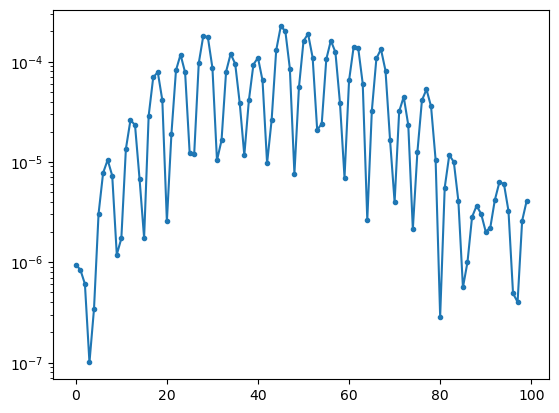

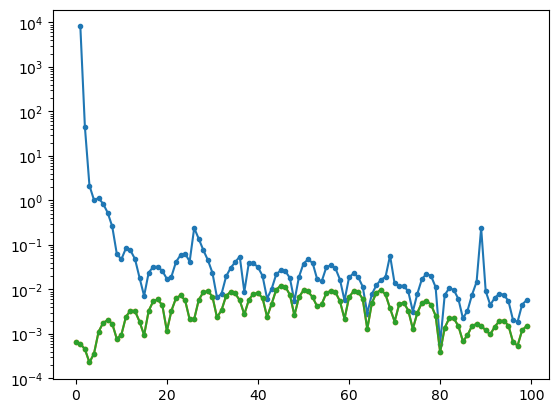

In [24]:
LOSS_data=0    
LOSS_data = tc.mean((S_pred - valor_esperado_data) ** 2,dim=1)

LOSS_edo  = 0
LOSS_edo += (dSx - (-1.0*Y))**2
LOSS_edo += (dSy - ( 1.0*X - 1.0*JX*Z))**2
LOSS_edo += (dSz - ( 1.0*JX*Y))**2

plt.plot(LOSS_data.cpu().detach().numpy(),".-")
#plt.plot(LOSS_edo.cpu().detach().numpy(),"k.-")
plt.yscale("log")
plt.show()

LOSS_data=0    
LOSS_data = tc.mean(abs(S_pred - valor_esperado_data)/abs(valor_esperado_data) ,dim=1)

plt.plot(LOSS_data.cpu().detach().numpy(),".-")
LOSS_data=0    
LOSS_data = tc.mean(abs(S_pred - valor_esperado_data) ,dim=1)
plt.plot(LOSS_data.cpu().detach().numpy(),".-")

LOSS_edo  = 0
LOSS_edo += abs(dSx - (-1.0*Y))
LOSS_edo += abs(dSy - ( 1.0*X - 1.0*JX*Z))
LOSS_edo += abs(dSz - ( 1.0*JX*Y))

plt.plot(LOSS_data.cpu().detach().numpy(),".-")
#plt.plot(LOSS_edo.cpu().detach().numpy(),"k.-")
plt.yscale("log")
plt.show()